# Weight Initialization in Deep Neural Networks

The primary goal of weight initialization in deep learning is to prevent the magnitude of activations and gradients from either vanishing (becoming too small) or exploding (becoming too large) as they propagate through the layers. Effective initialization allows the network to converge faster and achieve better performance.

Here is a breakdown of the key weight initialization techniques, categorized by their underlying approach.

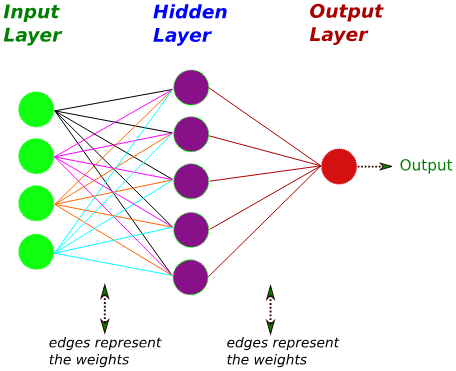


<h2><font color='magenta'> 1. Naive/Non-Recommended Initialization Techniques</font></h2>
These methods are generally unsuitable for deep neural networks due to fundamental issues:


<h3><font color='green'> 1.1 Zero / Constant Initialization</font></h3>

All weights are initialized to 0 or any other constant value ($k$).

**Problem**: This causes the symmetry problem. Every neuron in a layer will compute the exact same function, receive the exact same gradient during backpropagation, and thus update in the exact same way. This means the network has only one effective neuron per layer and cannot learn complex, diverse features.

**Biases**: Biases are often safely initialized to zero, as they do not suffer from the symmetry problem.

In [15]:
import tensorflow as tf
import numpy as np

# Set input/output dimensions
INPUT_DIM = 5  # fan_in
OUTPUT_DIM = 3 # fan_out

def initialize_and_display_zero():
    """Initializes a layer with Zeros and prints the weights and statistics."""
    
    # 1. Define the layer with Zero Initialization
    layer = tf.keras.layers.Dense(
        units=OUTPUT_DIM,
        activation='linear',
        kernel_initializer=tf.keras.initializers.Zeros(),
        name='Zero_Layer'
    )
    
    # 2. Build the layer and create the weights
    # The layer needs to process input data once to create its weights
    input_data = tf.random.normal((1, INPUT_DIM)) # Dummy input
    _ = layer(input_data)
    
    # 3. Retrieve and print the weights (kernel is the weight matrix W)
    # get_weights()[0] is the kernel (W), get_weights()[1] is the bias (b)
    weights = layer.get_weights()[0]
    
    print("### Initializer: Zero Initialization (Activation: Linear) ###")
    print("--"*30)
    print(f"Weight Matrix Shape: {weights.shape} (Input Features: {INPUT_DIM}, Output Units: {OUTPUT_DIM})")
    
    # Display the actual matrix
    print("\nInitial Weights (W):\n", weights)
    
    # Display statistics
    print(f"\nObservation: All weights are zero. Every neuron in this layer starts identical.")
    print(f"Mean: {np.mean(weights):.4f}")
    print(f"Standard Deviation (STD): {np.std(weights):.4f}")
    print("-" * 60)

# Execute the demonstration
initialize_and_display_zero()

### Initializer: Zero Initialization (Activation: Linear) ###
------------------------------------------------------------
Weight Matrix Shape: (5, 3) (Input Features: 5, Output Units: 3)

Initial Weights (W):
 [[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Observation: All weights are zero. Every neuron in this layer starts identical.
Mean: 0.0000
Standard Deviation (STD): 0.0000
------------------------------------------------------------


* When all weights are initialized to zero, the weight matrix $W$ is a zero matrix.

* During the forward pass, for any input $x$, the weighted sum for all neurons in the layer will be identical: $z_i = W_{i}x + b_i = 0$.

<h3><font color='green'>1.2 Small Random Initialization</font></h3>

Weights are drawn from a random distribution (e.g., Uniform or Normal) with a very small variance (e.g., $\mathcal{N}(0, 0.01^2)$).


**Problem**: 
- - While it breaks symmetry, the small weights cause the activations to shrink toward zero as they move deeper into the network. This leads to the vanishing gradient problem, where the gradients become tiny, making early layers learn extremely slowly or stall completely.<br>
- - The issue is **multiplicative shrinkage across many layers**:

$$
x_L \approx W_L W_{L-1} \dots W_1 x_0$$

If each $W$ has variance $< 1$ , the signal decays **exponentially with depth**. That’s the true engine of vanishing gradients—not just “small numbers,” but **repeated multiplication of small variances**.


In [14]:
import tensorflow as tf
import numpy as np

# Set input/output dimensions
INPUT_DIM = 5  # fan_in
OUTPUT_DIM = 3 # fan_out

def initialize_and_display_random_uniform():
    """Initializes a layer with Random Uniform and prints the weights and statistics."""
    
    # 1. Define the layer with RandomUniform Initialization
    # Common range for 'small random' is often U(-0.05, 0.05) or U(-0.1, 0.1)
    layer = tf.keras.layers.Dense(
        units=OUTPUT_DIM,
        activation='linear',
        kernel_initializer=tf.keras.initializers.RandomUniform(minval=-0.05, maxval=0.05, seed=42),
        name='Small_Random_Uniform_Layer'
    )
    
    # 2. Build the layer and create the weights
    # Process dummy input to trigger weight creation
    input_data = tf.random.normal((1, INPUT_DIM)) 
    _ = layer(input_data)
    
    # 3. Retrieve and print the weights (W)
    weights = layer.get_weights()[0]
    
    print("### Initializer: Small Random Uniform Initialization ###")
    print("--"*30)
    print(f"Distribution Range: [-0.05, 0.05]")
    print(f"Weight Matrix Shape: {weights.shape}")
    
    # Display the actual matrix
    print("\nInitial Weights (W):\n", weights)
    
    # Display statistics
    # Standard deviation (STD) for U(-a, a) is a / sqrt(3).
    # For a=0.05, STD ≈ 0.05 / 1.732 ≈ 0.0288
    print(f"\nObservation: Weights are small random numbers, breaking symmetry.")
    print(f"Mean: {np.mean(weights):.4f}")
    print(f"Standard Deviation (STD): {np.std(weights):.4f}")
    print("-" * 60)

# Execute the demonstration
initialize_and_display_random_uniform()

### Initializer: Small Random Uniform Initialization ###
------------------------------------------------------------
Distribution Range: [-0.05, 0.05]
Weight Matrix Shape: (5, 3)

Initial Weights (W):
 [[-0.02175668 -0.00015831  0.02154585]
 [-0.0479798  -0.04214019  0.01265594]
 [ 0.02549983 -0.03267942 -0.03712874]
 [-0.04473295  0.04425292 -0.02695481]
 [-0.00224584 -0.02534449  0.0224576 ]]

Observation: Weights are small random numbers, breaking symmetry.
Mean: -0.0103
Standard Deviation (STD): 0.0289
------------------------------------------------------------


* The weights are non-zero and distinct, which means different neurons will compute different functions, solving the symmetry problem.

*  The standard deviation is very small ($\approx 0.0288$). In a deep network, multiplying these small values across many layers causes the magnitude of the activations and their corresponding gradients to shrink exponentially, leading to vanishing gradients. This stalls learning, particularly for the early layers.

<h3><font color='green'>1.3 Large Random Initialization</font></h3>
In this, Weights are drawn from a random distribution with a large variance.

**Problem:** 
- - The large weights can cause the dot product inputs ($z = Wx + b$) to become very large, pushing the activation function (like Sigmoid or Tanh) into its saturation region. In this region, the derivative is near zero, also resulting in a vanishing gradient problem. 
- - For ReLU, large weights can cause exploding gradients or "dead" neurons if the bias is not large enough to keep the unit active.

* For **Sigmoid / Tanh** → large weights → **saturation → vanishing gradients** 
* For **ReLU** → large weights → **exploding activations and exploding gradients**
  
> This technique draws weights from a random distribution with a large standard deviation (e.g., $\mathcal{N}(0, 1^2)$). 

> The resulting large magnitudes cause the weighted input sum ($z = Wx + b$) to become very large, pushing the activation function into its saturated, near-zero-gradient regions.

In [13]:
import tensorflow as tf
import numpy as np

# Set input/output dimensions
INPUT_DIM = 5  # fan_in
OUTPUT_DIM = 3 # fan_out

def initialize_and_display_large_random():
    """Initializes a layer with Large Random weights and prints the weights and statistics."""
    
    # 1. Define the layer with RandomNormal Initialization (using a large standard deviation, e.g., 1.0)
    # This is often the default if no initialization is specified and the input/output dims are small.
    layer = tf.keras.layers.Dense(
        units=OUTPUT_DIM,
        activation='tanh', # Use Tanh to clearly show the saturation effect
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=1.0, seed=42),
        name='Large_Random_Normal_Layer'
    )
    
    # 2. Build the layer and create the weights
    # Process dummy input to trigger weight creation
    input_data = tf.random.normal((1, INPUT_DIM)) 
    _ = layer(input_data)
    
    # 3. Retrieve and print the weights (W)
    weights = layer.get_weights()[0]
    
    print("### Initializer: Large Random Normal Initialization ###")
    print("--"*30)
    print(f"Distribution: Normal(mean=0.0, stddev=1.0)")
    print(f"Weight Matrix Shape: {weights.shape}")
    
    # Display the actual matrix
    print("\nInitial Weights (W):\n", weights)
    
    # Display statistics
    print(f"\nObservation: Weights are large (stddev ≈ 1.0), leading to large input sums (z).")
    print(f"Mean: {np.mean(weights):.4f}")
    print(f"Standard Deviation (STD): {np.std(weights):.4f}")
    print("-" * 60)

# Execute the demonstration
initialize_and_display_large_random()

### Initializer: Large Random Normal Initialization ###
------------------------------------------------------------
Distribution: Normal(mean=0.0, stddev=1.0)
Weight Matrix Shape: (5, 3)

Initial Weights (W):
 [[ 0.01581708 -1.5900869   0.10359446]
 [ 0.81174594 -1.6103551  -1.5791047 ]
 [ 0.6641258   0.3478742   0.657962  ]
 [ 1.9150538   0.3414673   0.04215257]
 [ 1.2155311   0.02631431 -0.7969534 ]]

Observation: Weights are large (stddev ≈ 1.0), leading to large input sums (z).
Mean: 0.0377
Standard Deviation (STD): 1.0053
------------------------------------------------------------


* The standard deviation is high ($\approx 1.0$), confirming the large weight values.
* When these large weights are multiplied by input features, the resulting pre-activation values ($z$) will be large in magnitude (e.g., $+10$ or $-10$).
* For activation functions like $\mathbf{Tanh}$, large inputs push the output towards its maximum ($+1$) or minimum ($-1$) plateau. In these regions, the derivative (the gradient used in backpropagation) is essentially zero.$$\frac{d}{dz} \tanh(z) \approx 0 \quad \text{for large } |z|$$This causes the gradients to vanish, stalling the learning process, similar to the small random case, but due to saturation rather than small multiplications.

<h2><font color='magenta'> 2. Recommended Initialization Techniques</font></h2>

These modern techniques address the vanishing/exploding gradient problems by mathematically calculating the appropriate variance for the weights based on the number of nodes in inputs and/or outputs of layer ($\text{fan}_{\text{in}}$ and $\text{fan}_{\text{out}}$).
<h3><font color='green'>2.1 Xavier (Glorot) Initialization</font></h3>

This method was designed to ensure that the variance of the activations and the gradients remains roughly the same across every layer.
* **Optimal For**: Activation functions that are symmetric around zero and have a derivative near 1 at $x=0$, such as Tanh and Sigmoid.

* **Formula**: 

* * **Uniform**: Weights are sampled from a uniform distribution $U(-a, a)$, where
$$
a = \sqrt{\frac{6}{\text{fan}*{in} + \text{fan}*{out}}}
$$

* * **Normal**: Weights are sampled from a normal distribution $\mathcal{N}(0, \sigma^2)$, where the standard deviation $\sigma$ is:
$$
\sigma = \sqrt{\frac{2}{\text{fan}*{in} + \text{fan}*{out}}}
$$


In [29]:
import tensorflow as tf
import numpy as np

# Set input/output dimensions
INPUT_DIM = 5  # fan_in
OUTPUT_DIM = 3 # fan_out
TARGET_STD = 0.5 # sqrt(2 / (5 + 3))

def initialize_and_display_xavier_normal():
    """Initializes a layer with Xavier Normal and prints the weights and statistics."""
    
    # 1. Define the layer with GlorotNormal Initializer
    layer = tf.keras.layers.Dense(
        units=OUTPUT_DIM,
        activation='tanh',
        kernel_initializer=tf.keras.initializers.GlorotNormal(seed=42),
        name='Xavier_Normal_Layer'
    )
    
    # 2. Build the layer and create the weights
    input_data = tf.random.normal((1, INPUT_DIM)) 
    _ = layer(input_data)
    
    # 3. Retrieve and print the weights (W)
    weights = layer.get_weights()[0]
    
    print("### Initializer: Xavier (Glorot) Normal ###")
    print("--"*30)
    print(f"Activation Function: Tanh (Recommended)")
    print(f"Target STD: {TARGET_STD:.4f}")
    print(f"Weight Matrix Shape: {weights.shape}")
    
    # Display the actual matrix
    print("\nInitial Weights (W):\n", weights)
    
    # Display statistics
    print(f"\nObservation: Weights are normally distributed and centered around 0.")
    print(f"Mean: {np.mean(weights):.4f}")
    print(f"Actual Standard Deviation (STD): {np.std(weights):.4f}")
    print("-" * 60)

# Execute the demonstration
initialize_and_display_xavier_normal()

### Initializer: Xavier (Glorot) Normal ###
------------------------------------------------------------
Activation Function: Tanh (Recommended)
Target STD: 0.5000
Weight Matrix Shape: (5, 3)

Initial Weights (W):
 [[ 0.0089908  -0.903843    0.05888554]
 [ 0.46141556 -0.01216873  0.06711774]
 [-0.00318203 -0.0823064  -0.02683203]
 [ 0.5853077  -0.22790733  0.06818139]
 [ 0.4540369  -0.7764386  -0.30975458]]

Observation: Weights are normally distributed and centered around 0.
Mean: -0.0426
Actual Standard Deviation (STD): 0.3935
------------------------------------------------------------


In [33]:
import tensorflow as tf
import numpy as np

# Set input/output dimensions
INPUT_DIM = 5  # fan_in
OUTPUT_DIM = 3 # fan_out
TARGET_LIMIT = np.sqrt(6 / (INPUT_DIM + OUTPUT_DIM))

def initialize_and_display_xavier_uniform():
    """Initializes a layer with Xavier Uniform and prints the weights and statistics."""
    
    # 1. Define the layer with GlorotUniform Initializer
    layer = tf.keras.layers.Dense(
        units=OUTPUT_DIM,
        activation='tanh',
        kernel_initializer=tf.keras.initializers.GlorotUniform(seed=42),
        name='Xavier_Uniform_Layer'
    )
    
    # 2. Build the layer and create the weights
    input_data = tf.random.normal((1, INPUT_DIM)) 
    _ = layer(input_data)
    
    # 3. Retrieve and print the weights (W)
    weights = layer.get_weights()[0]
    
    print("### Initializer: Xavier (Glorot) Uniform ###")
    print("--"*30)
    print(f"Activation Function: Tanh (Recommended)")
    print(f"Target Range (-a, a): (-{TARGET_LIMIT:.4f}, {TARGET_LIMIT:.4f})")
    print(f"Weight Matrix Shape: {weights.shape}")
    
    # Display the actual matrix
    print("\nInitial Weights (W):\n", weights)
    
    # Display statistics
    print(f"\nObservation: Weights are uniformly spread between the limits.")
    print(f"Mean: {np.mean(weights):.4f}")
    print(f"Actual Standard Deviation (STD): {np.std(weights):.4f}")
    print("-" * 60)

# Execute the demonstration
initialize_and_display_xavier_uniform()

### Initializer: Xavier (Glorot) Uniform ###
------------------------------------------------------------
Activation Function: Tanh (Recommended)
Target Range (-a, a): (-0.8660, 0.8660)
Weight Matrix Shape: (5, 3)

Initial Weights (W):
 [[-0.37683684 -0.00274199  0.3731851 ]
 [-0.8310344  -0.7298894   0.21920723]
 [ 0.44167    -0.56602407 -0.6430885 ]
 [-0.77479744  0.766483   -0.46687093]
 [-0.03889912 -0.43897945  0.388977  ]]

Observation: Weights are uniformly spread between the limits.
Mean: -0.1786
Actual Standard Deviation (STD): 0.5003
------------------------------------------------------------


<h3><font color='green'>2.2 He (Kaiming) Initialization</font></h3>

- Xavier initialization often performs poorly with the Rectified Linear Unit (ReLU) activation function because ReLU is not symmetric around zero. 
- Since ReLU outputs zero for half of its input range (the negative part), it essentially halves the variance of the activations. He initialization accounts for this by scaling the variance up by a factor of 2.

**Optimal For**: Activation functions like ReLU and its variants (e.g., Leaky ReLU).

**Formula**: 

- - **Uniform**:
$$
a = \sqrt{\frac{6}{\text{fan}_{in}}}
$$

- - **Normal**:
$$
\sigma = \sqrt{\frac{2}{\text{fan}_{in}}}
$$

The use of $\text{fan}_{\text{in}}$ (number of input connections) is the most common default, aiming to stabilize the forward pass variance. Some frameworks may offer a "fan_out" or "fan_average" mode as well.

In [35]:
import tensorflow as tf
import numpy as np

# Set input/output dimensions
INPUT_DIM = 5  # fan_in
OUTPUT_DIM = 3 # fan_out
TARGET_STD = np.sqrt(2 / INPUT_DIM) # sqrt(2 / 5) ≈ 0.6325

def initialize_and_display_he_normal():
    """Initializes a layer with He Normal and prints the weights and statistics."""
    
    # 1. Define the layer with HeNormal Initializer
    layer = tf.keras.layers.Dense(
        units=OUTPUT_DIM,
        activation='relu', # Recommended activation
        kernel_initializer=tf.keras.initializers.HeNormal(seed=42),
        name='He_Normal_Layer'
    )
    
    # 2. Build the layer and create the weights
    input_data = tf.random.normal((1, INPUT_DIM)) 
    _ = layer(input_data)
    
    # 3. Retrieve and print the weights (W)
    weights = layer.get_weights()[0]
    
    print("### Initializer: He (Kaiming) Normal ###")
    print("--"*30)
    print(f"Activation Function: ReLU (Recommended)")
    print(f"Target STD: {TARGET_STD:.4f}")
    print(f"Weight Matrix Shape: {weights.shape}")
    
    # Display the actual matrix
    print("\nInitial Weights (W):\n", weights)
    
    # Display statistics
    print(f"\nObservation: STD is higher than Xavier uniform ({0.39:.2f} vs {0.49:.2f}) to compensate for ReLU's behavior.")
    print(f"Mean: {np.mean(weights):.4f}")
    print(f"Actual Standard Deviation (STD): {np.std(weights):.4f}")
    print("-" * 60)

# Execute the demonstration
initialize_and_display_he_normal()

### Initializer: He (Kaiming) Normal ###
------------------------------------------------------------
Activation Function: ReLU (Recommended)
Target STD: 0.6325
Weight Matrix Shape: (5, 3)

Initial Weights (W):
 [[ 0.01137256 -1.143281    0.07448497]
 [ 0.5836497  -0.01539236  0.08489797]
 [-0.00402498 -0.10411028 -0.03394013]
 [ 0.7403622  -0.2882825   0.08624339]
 [ 0.5743163  -0.98212576 -0.391812  ]]

Observation: STD is higher than Xavier uniform (0.39 vs 0.49) to compensate for ReLU's behavior.
Mean: -0.0538
Actual Standard Deviation (STD): 0.4977
------------------------------------------------------------


In [19]:
import tensorflow as tf
import numpy as np

# Set input/output dimensions
INPUT_DIM = 5  # fan_in
OUTPUT_DIM = 3 # fan_out
TARGET_LIMIT = np.sqrt(6 / INPUT_DIM)

def initialize_and_display_he_uniform():
    """Initializes a layer with He Uniform and prints the weights and statistics."""
    
    # 1. Define the layer with HeUniform Initializer
    layer = tf.keras.layers.Dense(
        units=OUTPUT_DIM,
        activation='relu',
        kernel_initializer=tf.keras.initializers.HeUniform(seed=42),
        name='He_Uniform_Layer'
    )
    
    # 2. Build the layer and create the weights
    input_data = tf.random.normal((1, INPUT_DIM)) 
    _ = layer(input_data)
    
    # 3. Retrieve and print the weights (W)
    weights = layer.get_weights()[0]
    
    print("### Initializer: He (Kaiming) Uniform ###")
    print("--"*30)
    print(f"Activation Function: ReLU (Recommended)")
    print(f"Target Range (-a, a): (-{TARGET_LIMIT:.4f}, {TARGET_LIMIT:.4f})")
    print(f"Weight Matrix Shape: {weights.shape}")
    
    # Display the actual matrix
    print("\nInitial Weights (W):\n", weights)
    
    # Display statistics
    print(f"\nObservation: Weights are uniformly spread, with limits optimized for ReLU.")
    print(f"Mean: {np.mean(weights):.4f}")
    print(f"Actual Standard Deviation (STD): {np.std(weights):.4f}")
    print("-" * 60)

# Execute the demonstration
initialize_and_display_he_uniform()

### Initializer: He (Kaiming) Uniform ###
------------------------------------------------------------
Activation Function: ReLU (Recommended)
Target Range (-a, a): (-1.0954, 1.0954)
Weight Matrix Shape: (5, 3)

Initial Weights (W):
 [[-0.47666508 -0.00346839  0.47204602]
 [-1.0511847  -0.92324525  0.2772777 ]
 [ 0.5586734  -0.71597016 -0.81344986]
 [-0.9800499   0.96953297 -0.59055024]
 [-0.04920399 -0.55527     0.49202132]]

Observation: Weights are uniformly spread, with limits optimized for ReLU.
Mean: -0.2260
Actual Standard Deviation (STD): 0.6328
------------------------------------------------------------


This increased variance is critical for ensuring the variance of the activations does not shrink in half after passing through the ReLU activation function, thereby preventing the vanishing gradient problem.


<h2><font color='magenta'> 3. Specialized Initialization Techniques</font></h2>
<h3><font color='green'>3.1. LeCun Initialization</font></h3>


* It uses only $\text{fan}_{in}$
* A precursor to Xavier, which is mathematically derived to work well with the SELU (Scaled Exponential Linear Unit) activation function, which is often used in self-normalizing networks. It uses a variance based only on $\text{fan}_{\text{in}}$.

The precise form is:

$$
\sigma^2 = \frac{1}{\text{fan}_{in}}
$$



In [37]:
import tensorflow as tf
import numpy as np

# Set input/output dimensions
INPUT_DIM = 5  # fan_in
OUTPUT_DIM = 3 # fan_out
TARGET_STD_LECUN = np.sqrt(1 / INPUT_DIM) # sqrt(1 / 5) ≈ 0.4472

def initialize_and_display_lecun_normal():
    """Initializes a layer with LeCun Normal and prints the weights and statistics."""
    
    # 1. Define the layer with LecunNormal Initializer
    # SELU activation is crucial for LeCun initialization
    layer = tf.keras.layers.Dense(
        units=OUTPUT_DIM,
        activation='selu',
        kernel_initializer=tf.keras.initializers.LecunNormal(seed=42),
        name='Lecun_Normal_Layer'
    )
    
    # 2. Build the layer and create the weights
    input_data = tf.random.normal((1, INPUT_DIM)) 
    _ = layer(input_data)
    
    # 3. Retrieve and print the weights (W)
    weights = layer.get_weights()[0]
    
    print("### Initializer: LeCun Normal ###")
    print("--"*30)
    print(f"Activation Function: SELU (Recommended)")
    print(f"Target STD: {TARGET_STD_LECUN:.4f}")
    print(f"Weight Matrix Shape: {weights.shape}")
    
    # Display the actual matrix
    print("\nInitial Weights (W):\n", weights)
    
    # Display statistics
    print(f"\nObservation: STD ({np.std(weights):.4f}) is targeted lower than Xavier or He.")
    print(f"Mean: {np.mean(weights):.4f}")
    print(f"Actual Standard Deviation (STD): {np.std(weights):.4f}")
    print("-" * 60)

# Execute the demonstration
initialize_and_display_lecun_normal()

### Initializer: LeCun Normal ###
------------------------------------------------------------
Activation Function: SELU (Recommended)
Target STD: 0.4472
Weight Matrix Shape: (5, 3)

Initial Weights (W):
 [[ 0.00804162 -0.80842173  0.05266883]
 [ 0.41270265 -0.01088404  0.06003192]
 [-0.00284609 -0.07361708 -0.02399929]
 [ 0.52351516 -0.20384651  0.06098329]
 [ 0.40610296 -0.6944678  -0.2770529 ]]

Observation: STD (0.3519) is targeted lower than Xavier or He.
Mean: -0.0381
Actual Standard Deviation (STD): 0.3519
------------------------------------------------------------



<h3><font color='green'> 3.2 Orthogonal Initialization</font></h3>

* Weights are initialized as a semi-orthogonal matrix. 
* This method is effective at preserving the norm of the signal across layers, which can be particularly useful in very deep networks like Recurrent Neural Networks (RNNs), as it helps mitigate vanishing/exploding gradients.
* Works best when combined with ReLU or linear activations


In [39]:
import tensorflow as tf
import numpy as np
from numpy.linalg import norm, matrix_rank

# Set input/output dimensions
INPUT_DIM = 5  # fan_in
OUTPUT_DIM = 3 # fan_out 

def initialize_and_display_orthogonal():
    """Initializes a layer with Orthogonal initializer and prints the weights and verification."""
    
    # 1. Define the layer with Orthogonal Initializer
    # Note: Orthogonal initialization is generally recommended for linear/tanh layers.
    layer = tf.keras.layers.Dense(
        units=OUTPUT_DIM,
        activation='linear',
        kernel_initializer=tf.keras.initializers.Orthogonal(seed=42),
        name='Orthogonal_Layer'
    )
    
    # 2. Build the layer and create the weights
    input_data = tf.random.normal((1, INPUT_DIM)) 
    _ = layer(input_data)
    
    # 3. Retrieve and print the weights (W)
    weights = layer.get_weights()[0]
    
    print("### Initializer: Orthogonal ###")
    print("--"*30)
    print(f"Weight Matrix Shape: {weights.shape}")
    
    # Display the actual matrix
    print("\nInitial Weights (W):\n", weights)
    
    # 4. Verification of Orthogonality (Crucial Step)
    # Check the property W^T W ≈ I (Identity Matrix)
    W_t_W = np.dot(weights.T, weights)
    
    print("\n--- Orthogonality Verification (W^T W): ---")
    print("If W is orthogonal, W^T W should be close to the Identity Matrix (I):\n", W_t_W)
    
    # Calculate difference from Identity Matrix (I)
    I = np.identity(OUTPUT_DIM) # I is 3x3
    difference = norm(W_t_W - I)
    
    print(f"\nObservation: The matrix successfully preserves the norm.")
    print(f"Norm of (W^T W - I): {difference:.4f} (Lower is better, ideal is 0)")
    print("-" * 60)

# Execute the demonstration
initialize_and_display_orthogonal()

### Initializer: Orthogonal ###
------------------------------------------------------------
Weight Matrix Shape: (5, 3)

Initial Weights (W):
 [[ 0.0063293  -0.68813914  0.60993135]
 [ 0.32482335 -0.67398965 -0.45184758]
 [ 0.26575255  0.16977869  0.47388434]
 [ 0.76631635  0.20303708  0.25478733]
 [ 0.48639956  0.04640889 -0.36651662]]

--- Orthogonality Verification (W^T W): ---
If W is orthogonal, W^T W should be close to the Identity Matrix (I):
 [[ 1.0000000e+00  1.5131782e-08 -6.8781262e-08]
 [ 1.5131782e-08  1.0000002e+00  6.5879838e-08]
 [-6.8781262e-08  6.5879838e-08  9.9999994e-01]]

Observation: The matrix successfully preserves the norm.
Norm of (W^T W - I): 0.0000 (Lower is better, ideal is 0)
------------------------------------------------------------
